TOP 10 BATTERS BY TOTAL RUNS

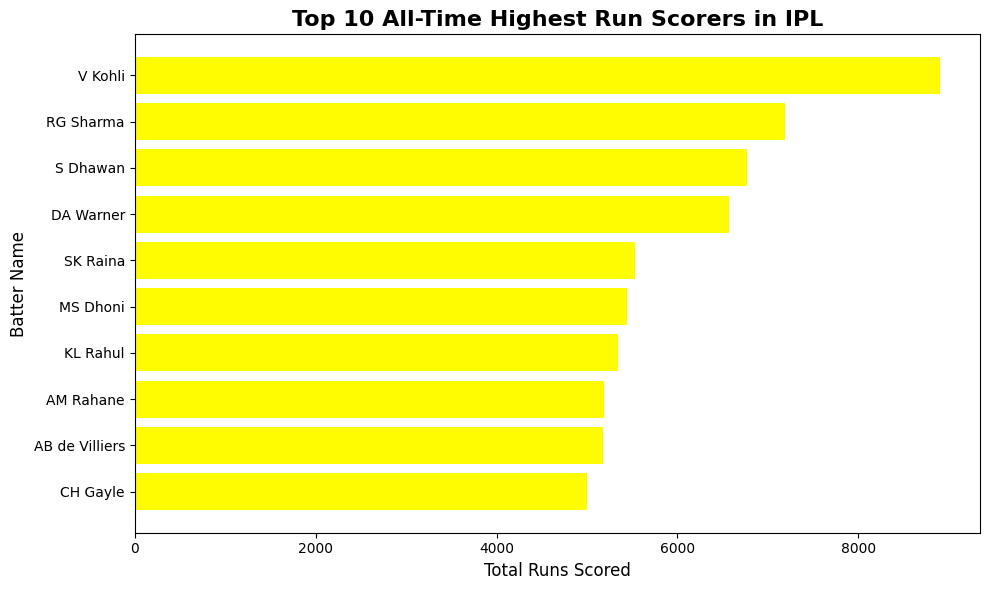

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

dataTOload =10

df = pd.read_csv('data/IPL.csv' , low_memory=False)

# Group by batters, sum runs, sort, and slice top 10
agg_scorers = df.groupby('batter')['runs_batter'].sum().reset_index()
top_10 = agg_scorers.sort_values(by='runs_batter', ascending=False).head(dataTOload)

# Initialize a local window/figure for the plot
# figsize width=10 inches, height=6 inch
plt.figure(figsize=(10, 6))

plt.barh(top_10['batter'], top_10['runs_batter'], color='#fffb00')

# Added custom details
plt.title(f'Top {dataTOload} All-Time Highest Run Scorers in IPL', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs Scored', fontsize=12)
plt.ylabel('Batter Name', fontsize=12)

# Invert the Y-axis so the #1 batsman sits at the very top of the graph
plt.gca().invert_yaxis()

# Automatically adjust padding so nothing gets clipped or cut off
plt.tight_layout()

# Display the graph in a popup window on your computer!
plt.show()

TOP 10 BALLERS BY THE TOTAL WICKET THROUGH OUT ALL SEASON

Displaying graph...


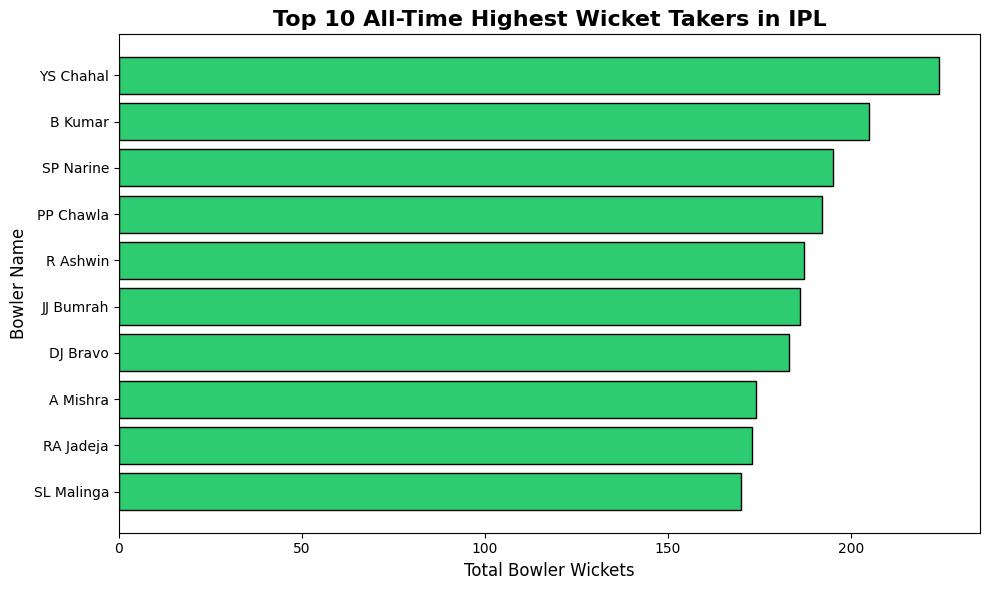

In [14]:
# Filter out rows where NO wicket fell
# If player_out is blank (NaN), it means no one was dismissed on that ball.
wicket_rows = df[df['player_out'].notna()]

# Filter out dismissals that do NOT belong to the bowler
# Run outs and retired hurts do not count toward a bowler's wicket tally.
non_bowler_dismissals = ['run out', 'retired hurt', 'obstructing the field']
bowler_wickets_df = wicket_rows[~wicket_rows['wicket_kind'].isin(non_bowler_dismissals)]

# Group by bowler and use .size() to count their rows (wickets)
# .size() counts the number of rows per bowler in our filtered "pure wicket" sheet
bowler_counts = bowler_wickets_df.groupby('bowler').size().reset_index(name='wickets')

# Sort from highest to lowest and grab the Top 10
top_10_bowlers = bowler_counts.sort_values(by='wickets', ascending=False).head(10)

plt.figure(figsize=(10, 6))

# Plotting a horizontal bar chart
plt.barh(top_10_bowlers['bowler'], top_10_bowlers['wickets'], color='#2ecc71', edgecolor='black')

# Decorating the graph
plt.title('Top 10 All-Time Highest Wicket Takers in IPL', fontsize=16, fontweight='bold')
plt.xlabel('Total Bowler Wickets', fontsize=12)
plt.ylabel('Bowler Name', fontsize=12)

# Invert Y-axis so the #1 bowler is at the top of the chart
plt.gca().invert_yaxis()
plt.tight_layout()

# Display the popup window on your computer
print("Displaying graph...")
plt.show()

In [6]:
print(df.columns)

Index(['match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter',
       'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket',
       'batting_partners', 'next_batter', 'striker_out'],
      dtype='s

TOP 10 SEASON WITH MOST OF THE RUNS

In [ ]:
runs_per_season_mean = df.groupby('season')['runs_total'].mean().reset_index()
runs_per_season_sum = df.groupby('season')['runs_total'].sum().reset_index()
top_10_per_season_runs = runs_per_season_sum.sort_values(by='runs_total', ascending=False).head(dataTOload)
print(top_10_per_season_runs)
top_10_per_season_runs['season'] = top_10_per_season_runs['season'].astype(str)
plt.figure(figsize=(10, 6))

# Plotting a horizontal bar chart
plt.barh(top_10_per_season_runs['season'], top_10_per_season_runs['runs_total'], color='#000', edgecolor='black')

# Decorating the graph
plt.title('Top 10 Seasons by Runs', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Season Year', fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()


plt.show()

TOP BATSMAN WITH MOST OF THE RUNS IN POWERPLAY

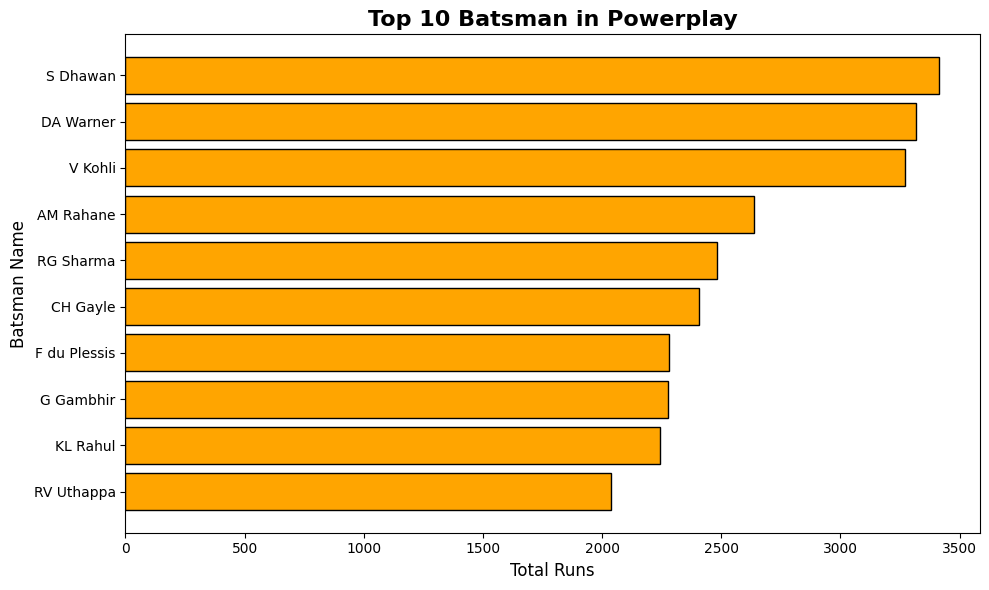

In [20]:
powerplay_df = df[df["over"] < 6]
powerplay_df = powerplay_df.reset_index(drop=True)
powerplay_runs = powerplay_df.groupby('batter')['runs_batter'].sum().reset_index()
top_10_powerplay = powerplay_runs.sort_values(by='runs_batter', ascending=False).head(10)

top_10_powerplay['batter'] = top_10_powerplay['batter'].astype(str)

plt.figure(figsize=(10, 6))
plt.barh(top_10_powerplay['batter'], top_10_powerplay['runs_batter'], color='orange', edgecolor='black')
plt.title('Top 10 Batsman in Powerplay', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Batsman Name', fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()


MOST OF THE TIME MAN OF THE MATCH

In [4]:
matches_df = df[['match_id', 'player_of_match']]

# Drop duplicate rows so we only have ONE row per match
# This shrinks 240+ rows per match down to exactly 1 row per match
unique_matches = matches_df.drop_duplicates(subset=['match_id'])

# value_counts() automatically groups, counts, and sorts from highest to lowest!
potm_counts = unique_matches['player_of_match'].value_counts().reset_index()

# Rename columns so they make sense
potm_counts.columns = ['player', 'awards_count']

top_10_potm = potm_counts.head(10)

plt.figure(figsize=(10, 6))

# Plot horizontal bars
plt.barh(top_10_potm['player'], top_10_potm['awards_count'], color='#9b59b6', edgecolor='black')

# Decorate the graph
plt.title('Top 10 Players with Most "Player of the Match" Awards', fontsize=16, fontweight='bold')
plt.xlabel('Number of Trophies', fontsize=12)
plt.ylabel('Player Name', fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

NameError: name 'plt' is not defined